In [ ]:
!pip install diffusers transformers accelerate --quiet
!pip install datasets --quiet
!pip install ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

import os
import gc
import torch
import clip
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [ ]:
from datasets import load_dataset

# Stream 1000 samples from the pixparse/cc3m-wds dataset
streamed_dataset = load_dataset("pixparse/cc3m-wds", split="train", streaming=True)

from itertools import islice
subset = list(islice(streamed_dataset, 10000))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.43k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

In [ ]:
# Assuming 'subset' already exists with 1000 entries
os.makedirs("cc3m_streamed_images", exist_ok=True)

image_paths = []
captions = []

for i, example in enumerate(subset):
    try:
        img = example["jpg"]
        caption = example["txt"]
        path = f"cc3m_streamed_images/img_{i}.jpg"
        img.save(path)
        image_paths.append(path)
        captions.append(caption)
    except Exception as e:
        print(f"Error at {i}: {e}")

In [ ]:
## TO CHECK THE IMAGES

# from IPython.display import display
# from PIL import Image

# # Show first 5 images
# for i in range(5):
#     img_path = f"cc3m_streamed_images/img_{i}.jpg"
#     img = Image.open(img_path)
#     print(f"Image {i}:", img_path)
#     display(img)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-L/14", device=device)

100%|███████████████████████████████████████| 890M/890M [00:21<00:00, 44.0MiB/s]


In [ ]:
batch_size = 32
image_embeddings = []
text_embeddings = []

progress = tqdm(range(0, len(image_paths), batch_size))

for i in progress:
    progress.write(f"📦 Processing batch starting at index {i}")

    paths_batch = image_paths[i:i+batch_size]
    captions_batch = captions[i:i+batch_size]
    images = []

    for path in paths_batch:
        try:
            img = Image.open(path).convert("RGB")
            images.append(preprocess(img))
        except:
            continue

    if len(images) == 0:
        continue

    image_input = torch.stack(images).to(device)
    text_input = clip.tokenize(captions_batch).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_input)

        # ✅ Normalize CLIP embeddings
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    image_embeddings.append(image_features.cpu())
    text_embeddings.append(text_features.cpu())


NameError: name 'tqdm' is not defined

In [ ]:
image_embeddings = torch.cat(image_embeddings, dim=0)
text_embeddings = torch.cat(text_embeddings, dim=0)

torch.save(image_embeddings, "clip_image_embeddings.pt")
torch.save(text_embeddings, "clip_text_embeddings.pt")

print("✅ Embeddings saved.")

✅ Embeddings saved.


In [ ]:
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device).eval()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

latents = []
for filename in tqdm(sorted(os.listdir("cc3m_streamed_images"))):
    path = os.path.join("cc3m_streamed_images", filename)
    try:
        img = Image.open(path).convert("RGB")
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            latent = vae.encode(img_tensor).latent_dist.sample() * 0.18215
        latents.append(latent.cpu())
    except Exception as e:
        print(f"Skipping {filename}: {e}")

latents_tensor = torch.cat(latents)
torch.save(latents_tensor, "vae_latents.pt")

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

100%|██████████| 10000/10000 [03:54<00:00, 42.67it/s]


In [ ]:
class LDMText2ImageDataset(Dataset):
    def __init__(self, latent_file, embedding_file):
        self.latents = torch.load(latent_file)
        self.embeddings = torch.load(embedding_file)
    def __len__(self):
        return len(self.latents)
    def __getitem__(self, idx):
        return {
            "latent": self.latents[idx],
            "embedding": self.embeddings[idx]
        }

dataset = LDMText2ImageDataset("vae_latents.pt", "clip_text_embeddings.pt")
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)


In [ ]:
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device).train()
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [ ]:
optimizer = AdamW(unet.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()

In [ ]:
import torch
import gc
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm
import matplotlib.pyplot as plt

  0%|          | 1/5000 [00:00<55:32,  1.50it/s]

[Epoch 1 | Step 0] Loss: 0.2227


  0%|          | 11/5000 [00:05<43:45,  1.90it/s]

[Epoch 1 | Step 10] Loss: 0.1119


  0%|          | 21/5000 [00:11<43:35,  1.90it/s]

...

[Epoch 5 | Step 4980] Loss: 0.0150


100%|█████████▉| 4991/5000 [44:16<00:04,  1.88it/s]

[Epoch 5 | Step 4990] Loss: 0.0408


100%|██████████| 5000/5000 [44:21<00:00,  1.88it/s]


✅ Epoch 5 completed. Avg Loss = 0.1352
✅ Saved model at epoch 5


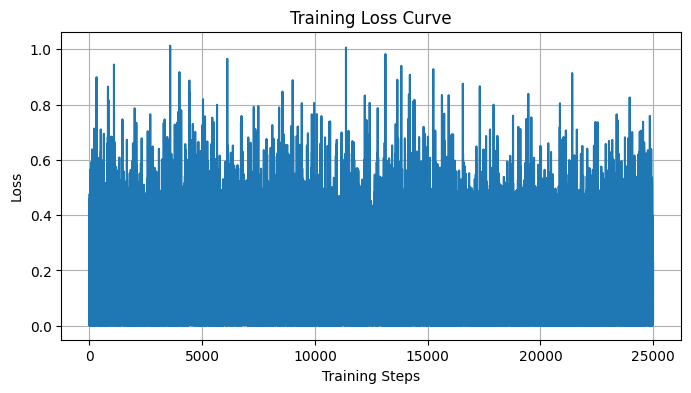

In [ ]:
scheduler = CosineAnnealingLR(optimizer, T_max=5)  # T_max = num_epochs
num_epochs = 5

losses = []  # To track loss for plotting

for epoch in range(num_epochs):
    unet.train()
    total_loss = 0

    for step, batch in enumerate(tqdm(dataloader)):
        try:
            # Move inputs to GPU and cast to float16 (for SD pretrained weights)
            latents = batch["latent"].float().to(device)
            text_embed = batch["embedding"].float().to(device)
            noise = torch.randn_like(latents).float()


            # Sample random timestep t
            bsz = latents.shape[0]
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (bsz,), device=device
            ).long()

            # Forward diffusion
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # UNet prediction
            text_embed = text_embed.unsqueeze(1)  # [B, 1, 768]
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample

            # Loss & optimization
            loss = mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()

            clip_grad_norm_(unet.parameters(), max_norm=1.0)  # 🚀 Gradient clipping
            optimizer.step()

            total_loss += loss.item()
            losses.append(loss.item())  # 🎯 Track for plotting

            if step % 10 == 0:
                print(f"[Epoch {epoch+1} | Step {step}] Loss: {loss.item():.4f}")

        except RuntimeError as e:
            print(f"[Step {step}] Runtime error: {e}")
            torch.cuda.empty_cache()
            gc.collect()
            continue

    scheduler.step()  # 📉 Update learning rate
    avg_loss = total_loss / len(dataloader)
    print(f"✅ Epoch {epoch+1} completed. Avg Loss = {avg_loss:.4f}")

    # 💾 Save model checkpoint
    torch.save(unet.state_dict(), f"unet_epoch_{epoch+1}.pt")
    print(f"✅ Saved model at epoch {epoch+1}")

# 📊 Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_path = "/content/drive/MyDrive/GenieVision/unet_epoch_5.pt"

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# ✅ Load UNet from pretrained and your trained weights
from diffusers import UNet2DConditionModel

unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet"
).to(device)

# 🔁 Load trained weights from epoch 5
unet.load_state_dict(torch.load(model_path, map_location=device))
unet.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [ ]:
# ✅ Load VAE decoder
vae = AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="vae"
).to(device).eval()

In [ ]:
clip_model, preprocess = clip.load("ViT-L/14", device=device)

In [ ]:
# ✅ Setup noise scheduler (DDPM)
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

In [ ]:
from torchvision.transforms.functional import to_pil_image

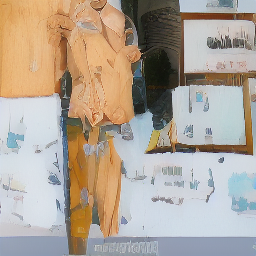

In [ ]:
# ✅ Define your text prompt
prompt = "beautiful beach"
tokens = clip.tokenize([prompt]).to(device)

with torch.no_grad():
    text_embed = clip_model.encode_text(tokens).float()
    text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)
    text_embed = text_embed.unsqueeze(1)  # [1, 1, 768]

# ✅ Start from random noise latent
latent = torch.randn(1, 4, 32, 32).to(device)

# ✅ Denoising loop
for t in scheduler.timesteps:
    with torch.no_grad():
        noise_pred = unet(latent, t, encoder_hidden_states=text_embed).sample
    latent = scheduler.step(noise_pred, t, latent).prev_sample

# ✅ Decode final latent to image
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample

# ✅ Convert and show/save image
img = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
display(img)
# img.save("generated_red_apple.png")